In [126]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
data = """experiment	train	test_ukr	test_covid	test_midterm	held_out
ukr_cov	single_ukr	0.9497	0.9741	0.884	midterm
ukr_cov	single_covid	0.9245	0.9815	0.8837	midterm
ukr_cov	merged_naive@match	0.9373	0.9778	0.8746	midterm
ukr_cov	merged_naive@full	0.9433	0.9807	0.8755	midterm
ukr_cov	merged_within@match	0.9447	0.9811	0.8835	midterm
ukr_cov	merged_within@full	0.9472	0.9822	0.8847	midterm
cov_mid	single_midterm	0.7935	0.8792	0.926	ukr
cov_mid	single_covid	0.9257	0.9813	0.886	ukr
cov_mid	merged_naive@match	0.9249	0.981	0.8849	ukr
cov_mid	merged_naive@full	0.924	0.9827	0.8899	ukr
cov_mid	merged_within@match	0.9243	0.9814	0.8943	ukr
cov_mid	merged_within@full	0.9244	0.9828	0.8984	ukr
cov_mid	merged_within_balanced@match	0.9216	0.978	0.9231	ukr
cov_mid	merged_within_balanced@full	0.9212	0.9796	0.9291	ukr"""

df = pd.read_csv(io.StringIO(data), sep='\t')


/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_83081/3601373002.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=15)


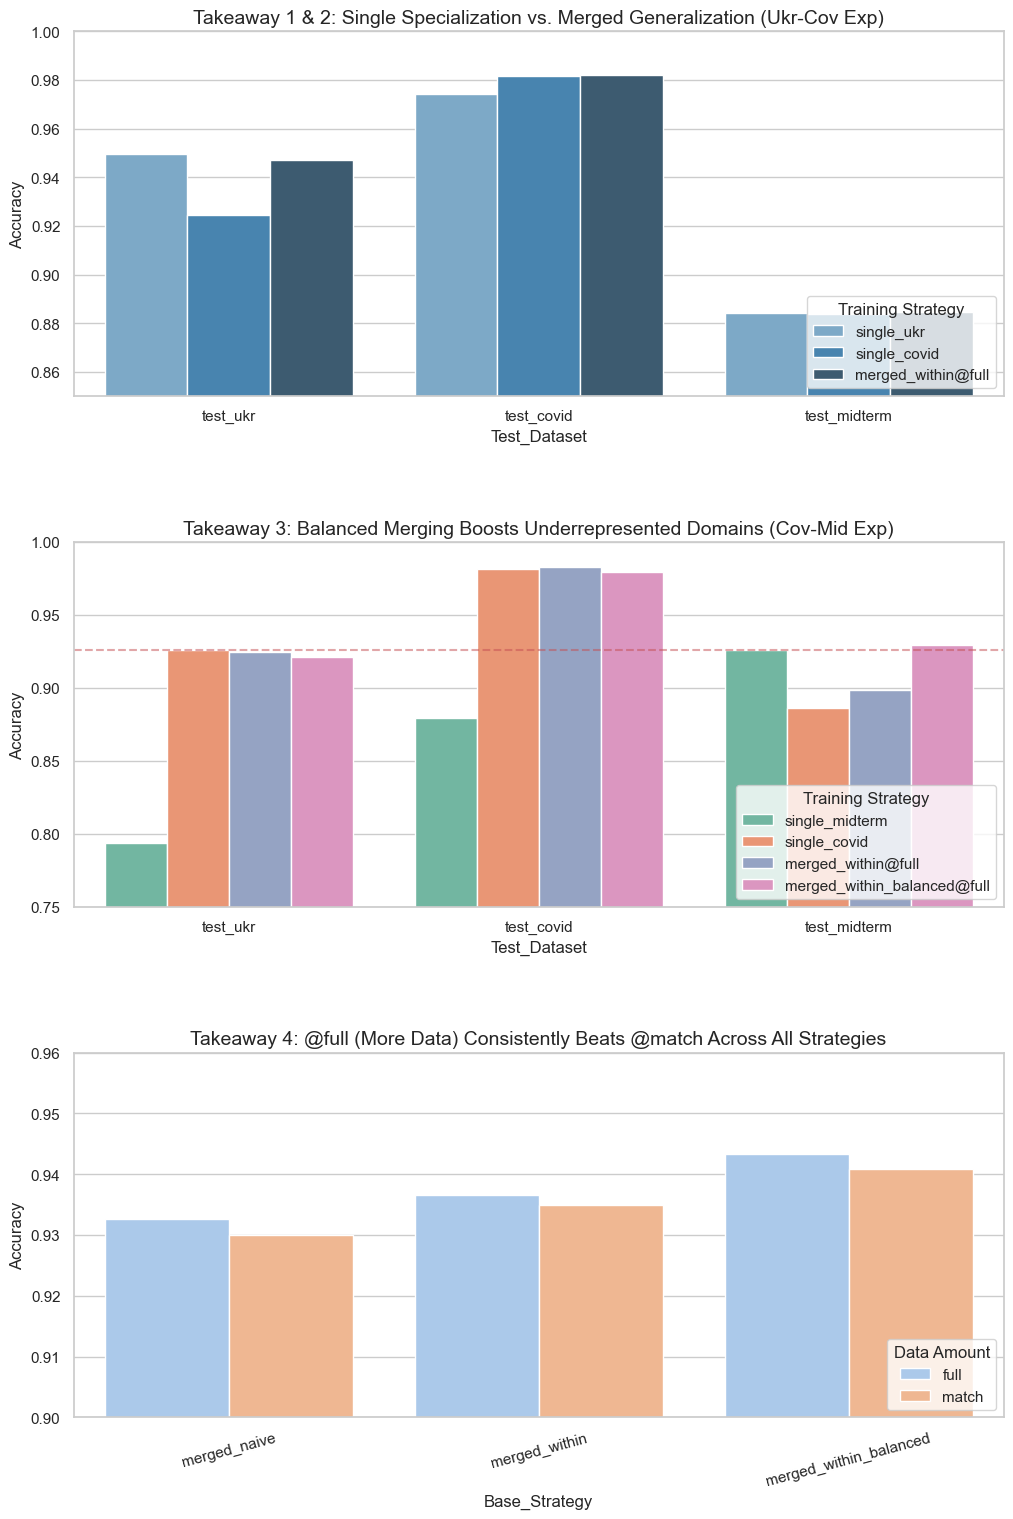

In [127]:

# Prepare dataframe for easy plotting (Melt test scores into one column)
df_melted = df.melt(id_vars=['experiment', 'train', 'held_out'], 
                    value_vars=['test_ukr', 'test_covid', 'test_midterm'],
                    var_name='Test_Dataset', value_name='Accuracy')

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
plt.subplots_adjust(hspace=0.4)

# --- PLOT 1: ukr_cov Experiment (Generalization vs Specialization) ---
# Filter to core models to show how merging keeps multi-domain performance high
ukr_cov_models = ['single_ukr', 'single_covid', 'merged_within@full']
df_ukr_cov = df_melted[(df_melted['experiment'] == 'ukr_cov') & 
                       (df_melted['train'].isin(ukr_cov_models))]

sns.barplot(data=df_ukr_cov, x='Test_Dataset', y='Accuracy', hue='train', ax=axes[0], palette='Blues_d')
axes[0].set_title('Takeaway 1 & 2: Single Specialization vs. Merged Generalization (Ukr-Cov Exp)', fontsize=14)
axes[0].set_ylim(0.85, 1.0)
axes[0].legend(title='Training Strategy', loc='lower right')

# --- PLOT 2: cov_mid Experiment (The power of balanced merging) ---
# Compare single midterm, naive merge, and balanced merge
cov_mid_models = ['single_covid', 'single_midterm', 'merged_within@full', 'merged_within_balanced@full']
df_cov_mid = df_melted[(df_melted['experiment'] == 'cov_mid') & 
                       (df_melted['train'].isin(cov_mid_models))]

sns.barplot(data=df_cov_mid, x='Test_Dataset', y='Accuracy', hue='train', ax=axes[1], palette='Set2')
axes[1].set_title('Takeaway 3: Balanced Merging Boosts Underrepresented Domains (Cov-Mid Exp)', fontsize=14)
axes[1].set_ylim(0.75, 1.0)
axes[1].legend(title='Training Strategy', loc='lower right')
axes[1].axhline(y=0.926, color='r', linestyle='--', alpha=0.5, label='Single Midterm Baseline')

# --- PLOT 3: @full vs @match Comparison ---
# Extract the base strategy and the matching condition
df['Base_Strategy'] = df['train'].apply(lambda x: x.split('@')[0] if '@' in x else x)
df['Match_Type'] = df['train'].apply(lambda x: x.split('@')[1] if '@' in x else 'Single')

# Filter out single models to only compare @match vs @full
df_match_full = df[df['Match_Type'] != 'Single'].copy()
# Melt again for the filtered dataframe
df_mf_melted = df_match_full.melt(id_vars=['experiment', 'Base_Strategy', 'Match_Type'], 
                                  value_vars=['test_ukr', 'test_covid', 'test_midterm'],
                                  var_name='Test_Dataset', value_name='Accuracy')

# Aggregate average accuracy across all tests for a macro comparison
df_agg = df_mf_melted.groupby(['Base_Strategy', 'Match_Type'])['Accuracy'].mean().reset_index()

sns.barplot(data=df_agg, x='Base_Strategy', y='Accuracy', hue='Match_Type', ax=axes[2], palette='pastel')
axes[2].set_title('Takeaway 4: @full (More Data) Consistently Beats @match Across All Strategies', fontsize=14)
axes[2].set_ylim(0.90, 0.96)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=15)
axes[2].legend(title='Data Amount', loc='lower right')

plt.show()

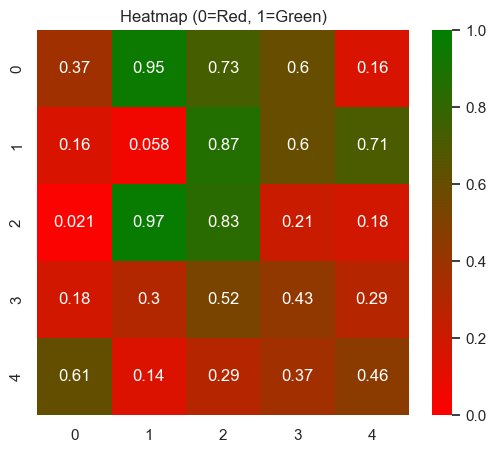

In [128]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Create some dummy data with values between 0 and 1
np.random.seed(42)
data = np.random.rand(5, 5)

# 2. Create a custom colormap: 0 = red, 1 = green
# If you want a middle color (like yellow for 0.5), you could use ["red", "yellow", "green"]
cmap = LinearSegmentedColormap.from_list("red_green", ["red", "green"])

# 3. Create the heatmap
fig, ax = plt.subplots(figsize=(6, 5))

# We set vmin=0 and vmax=1 to ensure the scale strictly maps 0 to the start (red) and 1 to the end (green)
sns.heatmap(data, cmap=cmap, vmin=0, vmax=1, annot=True, ax=ax)

ax.set_title("Heatmap (0=Red, 1=Green)")

# 4. Save or display the figure
plt.savefig("heatmap.png")
# plt.show() # Use this instead if you are running it locally and want a pop-up window

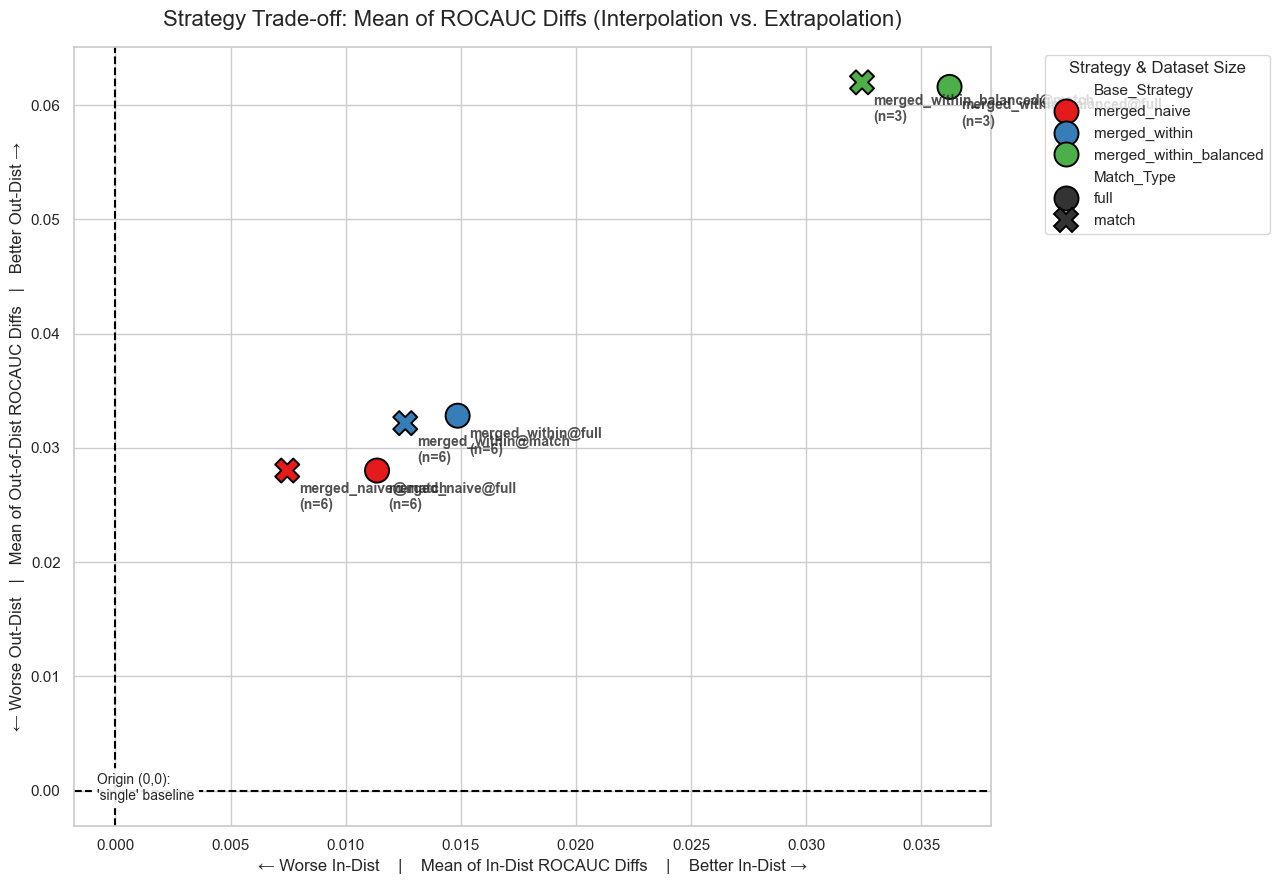

In [129]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
data = """experiment	train	test_ukr	test_covid	test_midterm	held_out
ukr_cov	single_ukr	0.9497	0.9741	0.884	midterm
ukr_cov	single_covid	0.9245	0.9815	0.8837	midterm
ukr_cov	merged_naive@match	0.9373	0.9778	0.8746	midterm
ukr_cov	merged_naive@full	0.9433	0.9807	0.8755	midterm
ukr_cov	merged_within@match	0.9447	0.9811	0.8835	midterm
ukr_cov	merged_within@full	0.9472	0.9822	0.8847	midterm
cov_mid	single_midterm	0.7935	0.8792	0.926	ukr
cov_mid	single_covid	0.9257	0.9813	0.886	ukr
cov_mid	merged_naive@match	0.9249	0.981	0.8849	ukr
cov_mid	merged_naive@full	0.924	0.9827	0.8899	ukr
cov_mid	merged_within@match	0.9243	0.9814	0.8943	ukr
cov_mid	merged_within@full	0.9244	0.9828	0.8984	ukr
cov_mid	merged_within_balanced@match	0.9216	0.978	0.9231	ukr
cov_mid	merged_within_balanced@full	0.9212	0.9796	0.9291	ukr"""

df = pd.read_csv(io.StringIO(data), sep='\t')

import pandas as pd
import io
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Melt and categorize data (Renamed value_name to ROCAUC)
df_melted = df.melt(id_vars=['experiment', 'train', 'held_out'], 
                    value_vars=['test_ukr', 'test_covid', 'test_midterm'],
                    var_name='Test_Dataset', value_name='ROCAUC')

def get_strategy(train_val):
    if train_val.startswith('single'): return 'single'
    # Keep the entire string to preserve the @full vs @match split
    return train_val 

def get_dist_type(row):
    train, exp, test = row['train'], row['experiment'], row['Test_Dataset']
    if train.startswith('single'):
        domain = train.split('_')[1] 
        return 'In-Distribution' if test == f'test_{domain}' else 'Out-of-Distribution'
    else:
        if exp == 'ukr_cov':
            return 'In-Distribution' if test in ['test_ukr', 'test_covid'] else 'Out-of-Distribution'
        elif exp == 'cov_mid':
            return 'In-Distribution' if test in ['test_covid', 'test_midterm'] else 'Out-of-Distribution'

df_melted['Strategy'] = df_melted['train'].apply(get_strategy)
df_melted['Distribution_Type'] = df_melted.apply(get_dist_type, axis=1)

# 3. Calculate Mean of Diffs and Counts
# Baseline
baseline_df = df_melted[df_melted['Strategy'] == 'single'].groupby(['experiment', 'Test_Dataset'])['ROCAUC'].mean().reset_index()
baseline_df.rename(columns={'ROCAUC': 'Baseline_ROCAUC'}, inplace=True)

# Merge and diff
df_melted = df_melted.merge(baseline_df, on=['experiment', 'Test_Dataset'])
df_melted['Row_Diff'] = df_melted['ROCAUC'] - df_melted['Baseline_ROCAUC']

# Aggregate by Mean AND Count (size)
agg_diffs = df_melted.groupby(['Strategy', 'Distribution_Type']).agg(
    Mean_Diff=('Row_Diff', 'mean'),
    Count=('Row_Diff', 'size')
).reset_index()

# 4. Pivot for Scatter Plot
df_pivot_mean = agg_diffs.pivot(index='Strategy', columns='Distribution_Type', values='Mean_Diff').reset_index()
df_pivot_count = agg_diffs.pivot(index='Strategy', columns='Distribution_Type', values='Count').reset_index()

# Merge the means and the counts back together horizontally
df_scatter = pd.merge(df_pivot_mean, df_pivot_count, on='Strategy', suffixes=('', '_count'))
df_scatter = df_scatter[df_scatter['Strategy'] != 'single'].copy()

# Add columns for styling (Hue vs Shape)
df_scatter['Base_Strategy'] = df_scatter['Strategy'].apply(lambda x: x.split('@')[0])
df_scatter['Match_Type'] = df_scatter['Strategy'].apply(lambda x: x.split('@')[1] if '@' in x else '')

# 5. Plotting
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 9))

# Plot with Base_Strategy for color and Match_Type for the marker shape
sns.scatterplot(data=df_scatter, x='In-Distribution', y='Out-of-Distribution', 
                hue='Base_Strategy', style='Match_Type', s=300, palette='Set1', edgecolor='black', ax=ax)

# Draw Baseline Origin lines
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')

# Shade quadrants
# ax.axhspan(0, df_scatter['Out-of-Distribution'].max() + 0.01, xmax=0.5, color='green', alpha=0.05)
# ax.axhspan(df_scatter['Out-of-Distribution'].min() - 0.01, 0, xmax=0.5, color='red', alpha=0.05)

# Annotate points with strategy and sample size (n)
for idx, row in df_scatter.iterrows():
    # Calculate total N by summing in-dist tests and out-dist tests for that dot
    total_n = int(row['In-Distribution_count'] + row['Out-of-Distribution_count'])
    
    # Format the label
    label = f"{row['Strategy']}\n(n={total_n})"
    
    # Position text slightly off the dot
    ax.text(row['In-Distribution'] + 0.0005, row['Out-of-Distribution'] - 0.001, 
            label, fontsize=10, fontweight='bold', alpha=0.8, verticalalignment='top')

ax.set_title("Strategy Trade-off: Mean of ROCAUC Diffs (Interpolation vs. Extrapolation)", fontsize=16, pad=15)
ax.set_xlabel("← Worse In-Dist    |    Mean of In-Dist ROCAUC Diffs    |    Better In-Dist →", fontsize=12)
ax.set_ylabel("← Worse Out-Dist   |   Mean of Out-of-Dist ROCAUC Diffs   |   Better Out-Dist →", fontsize=12)

# Move legend outside
ax.legend(title="Strategy & Dataset Size", bbox_to_anchor=(1.05, 1), loc='upper left')

# Label origin
props = dict(boxstyle='round', facecolor='white', alpha=0.9)
ax.text(ax.get_xlim()[0] + 0.001, ax.get_ylim()[0] + 0.002, "Origin (0,0):\n'single' baseline", fontsize=10, bbox=props, verticalalignment='bottom')

plt.tight_layout()
# plt.savefig("scatter_mean_of_diffs_split.png")
# plt.show()

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_83081/1808404330.py:317: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


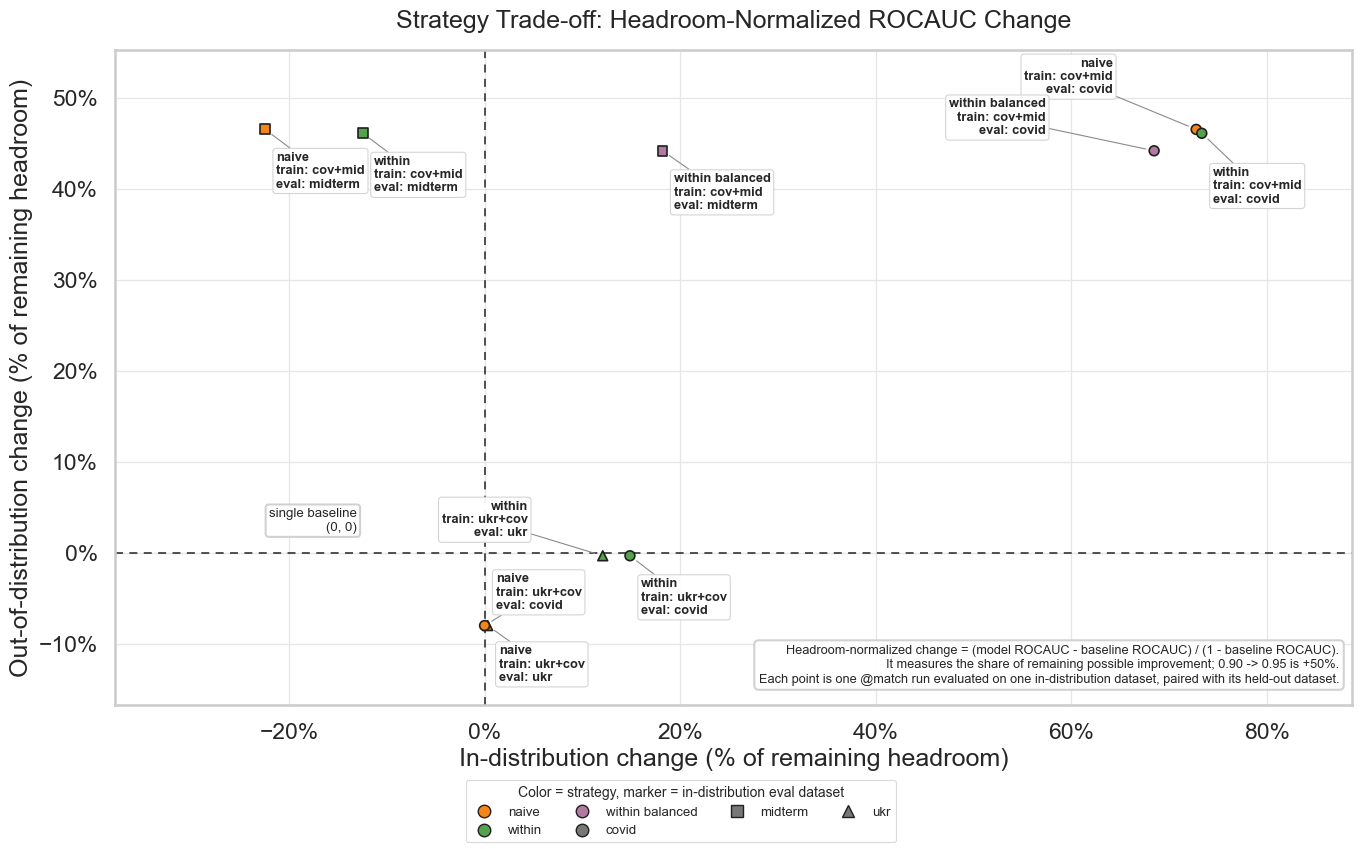

In [142]:
from __future__ import annotations

import io
import os
import tempfile
from pathlib import Path


# PLOT_DIR = Path(__file__).resolve().parent
CACHE_DIR = Path(tempfile.gettempdir()) / "prodigy-plot-cache"
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg"))

import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
import pandas as pd
import seaborn as sns


DATA = """experiment	train	test_ukr	test_covid	test_midterm	held_out
ukr_cov	single_ukr	0.9497	0.9741	0.884	midterm
ukr_cov	single_covid	0.9245	0.9815	0.8837	midterm
ukr_cov	merged_naive@match	0.9373	0.9778	0.8746	midterm
ukr_cov	merged_naive@full	0.9433	0.9807	0.8755	midterm
ukr_cov	merged_within@match	0.9447	0.9811	0.8835	midterm
ukr_cov	merged_within@full	0.9472	0.9822	0.8847	midterm
cov_mid	single_midterm	0.7935	0.8792	0.926	ukr
cov_mid	single_covid	0.9257	0.9813	0.886	ukr
cov_mid	merged_naive@match	0.9249	0.981	0.8849	ukr
cov_mid	merged_naive@full	0.924	0.9827	0.8899	ukr
cov_mid	merged_within@match	0.9243	0.9814	0.8943	ukr
cov_mid	merged_within@full	0.9244	0.9828	0.8984	ukr
cov_mid	merged_within_balanced@match	0.9216	0.978	0.9231	ukr
cov_mid	merged_within_balanced@full	0.9212	0.9796	0.9291	ukr"""


LABEL_OFFSETS = {
    "ukr_cov|merged_naive@match|test_ukr": (8, -14),
    "ukr_cov|merged_naive@match|test_covid": (8, 10),
    "ukr_cov|merged_within@match|test_ukr": (-54, 12),
    "ukr_cov|merged_within@match|test_covid": (8, -16),
    "cov_mid|merged_naive@match|test_covid": (-60, 24),
    "cov_mid|merged_naive@match|test_midterm": (8, -16),
    "cov_mid|merged_within@match|test_covid": (8, -24),
    "cov_mid|merged_within@match|test_midterm": (8, -16),
    "cov_mid|merged_within_balanced@match|test_covid": (-78, 10),
    "cov_mid|merged_within_balanced@match|test_midterm": (8, -16),
}


def strategy_name(train_value: str) -> str:
    if train_value.startswith("single"):
        return "single"
    return train_value


def distribution_type(row: pd.Series) -> str:
    train = row["train"]
    experiment = row["experiment"]
    test_dataset = row["Test_Dataset"]

    if train.startswith("single"):
        domain = train.split("_", maxsplit=1)[1]
        return "In-Distribution" if test_dataset == f"test_{domain}" else "Out-of-Distribution"

    if experiment == "ukr_cov":
        in_dist = test_dataset in {"test_ukr", "test_covid"}
    elif experiment == "cov_mid":
        in_dist = test_dataset in {"test_covid", "test_midterm"}
    else:
        raise ValueError(f"Unknown experiment: {experiment}")

    return "In-Distribution" if in_dist else "Out-of-Distribution"


def build_scatter_frame() -> pd.DataFrame:
    df = pd.read_csv(io.StringIO(DATA), sep="\t")
    melted = df.melt(
        id_vars=["experiment", "train", "held_out"],
        value_vars=["test_ukr", "test_covid", "test_midterm"],
        var_name="Test_Dataset",
        value_name="ROCAUC",
    )
    melted["Strategy"] = melted["train"].apply(strategy_name)
    melted["Distribution_Type"] = melted.apply(distribution_type, axis=1)

    baseline = (
        melted[melted["Strategy"] == "single"]
        .groupby(["experiment", "Test_Dataset"], as_index=False)["ROCAUC"]
        .mean()
        .rename(columns={"ROCAUC": "Baseline_ROCAUC"})
    )

    melted = melted.merge(baseline, on=["experiment", "Test_Dataset"], validate="many_to_one")
    if (melted["Baseline_ROCAUC"] >= 1).any():
        raise ValueError("Cannot normalize by remaining headroom when a baseline ROCAUC is >= 1.")
    melted["Headroom_Normalized_Diff"] = (
        melted["ROCAUC"] - melted["Baseline_ROCAUC"]
    ) / (1 - melted["Baseline_ROCAUC"])

    merged = melted[melted["Strategy"] != "single"].copy()
    merged["Base_Strategy"] = merged["Strategy"].str.split("@").str[0]
    merged["Match_Type"] = merged["Strategy"].str.split("@").str[1]
    merged = merged[merged["Match_Type"] == "match"].copy()

    point_keys = ["experiment", "train", "held_out", "Strategy", "Base_Strategy", "Match_Type"]
    in_dist = (
        merged[merged["Distribution_Type"] == "In-Distribution"]
        [point_keys + ["Test_Dataset", "Headroom_Normalized_Diff"]]
        .rename(
            columns={
                "Test_Dataset": "In_Test_Dataset",
                "Headroom_Normalized_Diff": "In-Distribution",
            }
        )
    )
    out_dist = (
        merged[merged["Distribution_Type"] == "Out-of-Distribution"]
        [point_keys + ["Test_Dataset", "Headroom_Normalized_Diff"]]
        .rename(
            columns={
                "Test_Dataset": "Out_Test_Dataset",
                "Headroom_Normalized_Diff": "Out-of-Distribution",
            }
        )
    )
    scatter = in_dist.merge(
        out_dist,
        on=point_keys,
        validate="many_to_one",
    )
    scatter["Base_Strategy"] = scatter["Strategy"].str.split("@").str[0]
    scatter["Match_Type"] = scatter["Strategy"].str.split("@").str[1]
    scatter["Point_ID"] = (
        scatter["experiment"] + "|" + scatter["Strategy"] + "|" + scatter["In_Test_Dataset"]
    )
    return scatter


def format_label(row: pd.Series) -> str:
    base = row["Base_Strategy"].replace("merged_", "").replace("_", " ")
    trained_model = row["experiment"].replace("_", "+")
    test_dataset = row["In_Test_Dataset"].replace("test_", "")
    return f"{base}\ntrain: {trained_model}\neval: {test_dataset}"


def padded_limits(values: pd.Series, extra: float = 0.16) -> tuple[float, float]:
    low = min(values.min(), 0)
    high = max(values.max(), 0)
    span = high - low
    pad = max(span * extra, 0.004)
    return low - pad, high + pad


def plot() -> tuple[Path, Path]:
    scatter = build_scatter_frame()

    sns.set_theme(style="whitegrid", context="talk")
    fig, ax = plt.subplots(figsize=(13.5, 8.4), layout="constrained")

    palette = {
        "merged_naive": "#4C78A8",
        "merged_naive": "#F58518",
        "merged_within": "#54A24B",
        "merged_within_balanced": "#B279A2",
    }
    markers = {
        "test_covid": "o",
        "test_midterm": "s",
        "test_ukr": "^",
    }
    sns.scatterplot(
        data=scatter,
        x="In-Distribution",
        y="Out-of-Distribution",
        hue="Base_Strategy",
        style="In_Test_Dataset",
        palette=palette,
        markers=markers,
        s=50,
        edgecolor="#1f1f1f",
        linewidth=1.2,
        ax=ax,
        zorder=3,
    )

    ax.axhline(0, color="#2b2b2b", linewidth=1.15, linestyle=(0, (5, 4)), zorder=1)
    ax.axvline(0, color="#2b2b2b", linewidth=1.15, linestyle=(0, (5, 4)), zorder=1)
    ax.set_xlim(*padded_limits(scatter["In-Distribution"]))
    ax.set_ylim(*padded_limits(scatter["Out-of-Distribution"]))

    for _, row in scatter.iterrows():
        dx, dy = LABEL_OFFSETS[row["Point_ID"]]
        ax.annotate(
            format_label(row),
            xy=(row["In-Distribution"], row["Out-of-Distribution"]),
            xytext=(dx, dy),
            textcoords="offset points",
            ha="left" if dx >= 0 else "right",
            va="bottom" if dy >= 0 else "top",
            fontsize=9.3,
            fontweight="semibold",
            linespacing=1.15,
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "white",
                "edgecolor": "#d2d2d2",
                "linewidth": 0.8,
                "alpha": 0.94,
            },
            arrowprops={
                "arrowstyle": "-",
                "color": "#8a8a8a",
                "linewidth": 0.8,
                "shrinkA": 0,
                "shrinkB": 6,
            },
            zorder=4,
        )

    ax.annotate(
        "single baseline\n(0, 0)",
        xy=(0, 0),
        xytext=(-92, 14),
        textcoords="offset points",
        fontsize=9.5,
        ha="right",
        va="bottom",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": "#cfcfcf",
            "alpha": 0.94,
        },
        zorder=4,
    )

    ax.text(
        0.99,
        0.03,
        "Headroom-normalized change = (model ROCAUC - baseline ROCAUC) / (1 - baseline ROCAUC).\n"
        "It measures the share of remaining possible improvement; 0.90 -> 0.95 is +50%.\n"
        "Each point is one @match run evaluated on one in-distribution dataset, paired with its held-out dataset.",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9.2,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": "#d0d0d0",
            "alpha": 0.95,
        },
        zorder=4,
    )

    ax.set_title("Strategy Trade-off: Headroom-Normalized ROCAUC Change", pad=16)
    ax.set_xlabel("In-distribution change (% of remaining headroom)")
    ax.set_ylabel("Out-of-distribution change (% of remaining headroom)")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.grid(True, color="#e6e6e6", linewidth=0.9)
    ax.set_axisbelow(True)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    strategy_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            label=name.replace("merged_", "").replace("_", " "),
            markerfacecolor=color,
            markeredgecolor="#1f1f1f",
            markersize=9,
        )
        for name, color in palette.items()
    ]
    marker_handles = [
        Line2D(
            [0],
            [0],
            marker=marker,
            color="none",
            label=dataset.replace("test_", ""),
            markerfacecolor="#777777",
            markeredgecolor="#1f1f1f",
            markersize=9,
        )
        for dataset, marker in markers.items()
    ]
    legend = fig.legend(
        handles=[*strategy_handles, *marker_handles],
        title="Color = strategy, marker = in-distribution eval dataset",
        loc="outside lower center",
        ncol=4,
        frameon=True,
        fontsize=9.5,
        title_fontsize=10,
    )
    legend.get_frame().set_edgecolor("#d0d0d0")
    legend.get_frame().set_linewidth(0.8)

    # png_path = PLOT_DIR / "strategy_tradeoff_headroom_normalized_roauc.png"
    # pdf_path = PLOT_DIR / "strategy_tradeoff_headroom_normalized_roauc.pdf"
    # fig.savefig(png_path, dpi=400, bbox_inches="tight", facecolor="white")
    # fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    # plt.close(fig)
    # plt.show()
    fig.show()
    return fig
    # return png_path, pdf_path

%matplotlib inline
plot()
%matplotlib inline

In [143]:
test_cols = [c for c in df.columns if c.startswith("test_")]

experiment_graphs = {
    "ukr_cov": ("ukr", "covid"),
    "cov_mid": ("covid", "midterm"),
}

long = df.melt(
    id_vars=["experiment", "train", "held_out"],
    value_vars=test_cols,
    var_name="graph",
    value_name="score",
)

long["graph"] = long["graph"].str.replace("^test_", "", regex=True)
long["is_control"] = long["train"].str.startswith("single_")
long["merged_graphs"] = long["experiment"].map(experiment_graphs)

controls = long[long["is_control"]].copy()
controls["control_graph"] = controls["train"].str.replace("^single_", "", regex=True)

controls = controls[
    (controls["graph"] == controls["control_graph"])
    | (controls["graph"] == controls["held_out"])
].copy()

controls["dist"] = controls.apply(
    lambda r: "in-dist" if r["graph"] == r["control_graph"] else "out-dist",
    axis=1,
)

controls = controls.rename(
    columns={
        "train": "control",
        "score": "control_score",
    }
)

controls = controls[
    [
        "experiment",
        "merged_graphs",
        "control",
        "control_graph",
        "graph",
        "dist",
        "control_score",
    ]
]

merged_models = long[~long["is_control"]].copy()

merged_deltas = merged_models.merge(
    controls,
    on=["experiment", "merged_graphs", "graph"],
    how="inner",
)

merged_deltas["delta"] = merged_deltas["score"] - merged_deltas["control_score"]

single_deltas = controls.copy()
single_deltas["train"] = single_deltas["control"]
single_deltas["score"] = single_deltas["control_score"]
single_deltas["delta"] = 0.0

delta_table = pd.concat(
    [
        merged_deltas,
        single_deltas,
    ],
    ignore_index=True,
)

delta_table = delta_table[
    [
        "experiment",
        "merged_graphs",
        "train",
        "control",
        "control_graph",
        "graph",
        "dist",
        "score",
        "control_score",
        "delta",
    ]
].sort_values(
    ["experiment", "train", "control", "dist", "graph"]
).reset_index(drop=True)

# delta_table

In [148]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plot = delta_table.copy()

plot["merge_strategy"] = (
    plot["train"]
    .str.replace(r"^merged_", "", regex=True)
    .str.replace(r"@.*$", "", regex=True)
)

plot["merge_size"] = (
    plot["train"]
    .str.extract(r"@(match|full)$", expand=False)
    .fillna("single")
)

# Only tests on the two graphs that make up the merged graph, excluding held-out C
component = plot[plot["control_relation"].isin(["same-target", "other-component"])].copy()

component_map = (
    component.pivot_table(
        index=[
            "experiment",
            "train_graphs",
            "train",
            "merge_strategy",
            "merge_size",
            "control",
            "control_graph",
        ],
        columns="control_relation",
        values="delta_dprime",
        aggfunc="first",
    )
    .reset_index()
    .rename(
        columns={
            "same-target": "x_in_delta",
            "other-component": "y_out_delta",
        }
    )
)

component_map

control_relation,experiment,train_graphs,train,merge_strategy,merge_size,control,control_graph,y_out_delta,x_in_delta
0,cov_mid,"(covid, midterm)",merged_naive@full,naive,full,single_covid,covid,0.028949,0.044743
1,cov_mid,"(covid, midterm)",merged_naive@full,naive,full,single_midterm,midterm,1.332206,-0.312026
2,cov_mid,"(covid, midterm)",merged_naive@match,naive,match,single_covid,covid,-0.008037,-0.009215
3,cov_mid,"(covid, midterm)",merged_naive@match,naive,match,single_midterm,midterm,1.278248,-0.349011
4,cov_mid,"(covid, midterm)",merged_within@full,within,full,single_covid,covid,0.094697,0.048056
5,cov_mid,"(covid, midterm)",merged_within@full,within,full,single_midterm,midterm,1.335519,-0.246278
6,cov_mid,"(covid, midterm)",merged_within@match,within,match,single_covid,covid,0.062506,0.003100
7,cov_mid,"(covid, midterm)",merged_within@match,within,match,single_midterm,midterm,1.290562,-0.278469
8,cov_mid,"(covid, midterm)",merged_within_balanced@full,within_balanced,full,single_covid,covid,0.372778,-0.050648
9,cov_mid,"(covid, midterm)",merged_within_balanced@full,within_balanced,full,single_midterm,midterm,1.236814,0.031804


In [ ]:
DATA = """experiment	train	test_ukr	test_covid	test_midterm	held_out
ukr_cov	single_ukr	0.9497	0.9741	0.884	midterm
ukr_cov	single_covid	0.9245	0.9815	0.8837	midterm
ukr_cov	merged_naive@match	0.9373	0.9778	0.8746	midterm
ukr_cov	merged_naive@full	0.9433	0.9807	0.8755	midterm
ukr_cov	merged_within@match	0.9447	0.9811	0.8835	midterm
ukr_cov	merged_within@full	0.9472	0.9822	0.8847	midterm
cov_mid	single_midterm	0.7935	0.8792	0.926	ukr
cov_mid	single_covid	0.9257	0.9813	0.886	ukr
cov_mid	merged_naive@match	0.9249	0.981	0.8849	ukr
cov_mid	merged_naive@full	0.924	0.9827	0.8899	ukr
cov_mid	merged_within@match	0.9243	0.9814	0.8943	ukr
cov_mid	merged_within@full	0.9244	0.9828	0.8984	ukr
cov_mid	merged_within_balanced@match	0.9216	0.978	0.9231	ukr
cov_mid	merged_within_balanced@full	0.9212	0.9796	0.9291	ukr"""

df = pd.read_csv(io.StringIO(DATA), sep="\t")

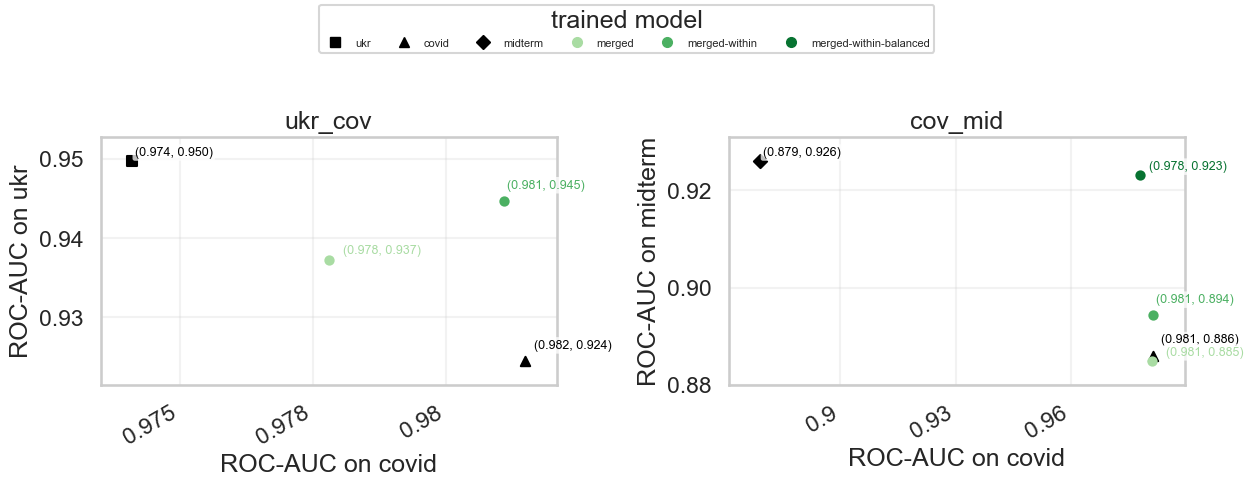

In [200]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FuncFormatter

HAS_ADJUST_TEXT = False

experiments = {
    "ukr_cov": ("test_covid", "test_ukr"),
    "cov_mid": ("test_covid", "test_midterm"),
}

plot_df = df[
    df["train"].str.startswith("single_")
    | df["train"].str.endswith("@match")
].copy()

def train_group(train):
    if train.startswith("single_"):
        return "single"

    base = train.removesuffix("@match")

    return {
        "merged_naive": "merged",
        "merged_within": "merged-within",
        "merged_within_balanced": "merged-within-balanced",
    }.get(base, base)

single_trains = list(dict.fromkeys(
    plot_df.loc[plot_df["train"].str.startswith("single_"), "train"]
))

single_marker_cycle = [
    "s",  # square
    "^",  # triangle up
    "D",  # diamond
    "P",  # plus-filled
    "X",  # x-filled
    "v",  # triangle down
    "<",
    ">",
    "p",
    "*",
    "h",
    "8",
]

marker_by_single_train = {
    train: single_marker_cycle[i % len(single_marker_cycle)]
    for i, train in enumerate(single_trains)
}

color_by_group = {
    "single": "black",
    "merged": plt.get_cmap("Greens")(0.35),
    "merged-within": plt.get_cmap("Greens")(0.60),
    "merged-within-balanced": plt.get_cmap("Greens")(0.85),
}

marker_by_group = {
    "merged": "o",
    "merged-within": "o",
    "merged-within-balanced": "o",
}

size_by_group = {
    "single": 45,
    "merged": 35,
    "merged-within": 35,
    "merged-within-balanced": 35,
}

def marker_for_train(train):
    group = train_group(train)
    if group == "single":
        return marker_by_single_train[train]
    return marker_by_group[group]

def color_for_train(train):
    return color_by_group[train_group(train)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

coord_decimals = 3

for ax, (experiment, (x_col, y_col)) in zip(axes, experiments.items()):
    d = plot_df[plot_df["experiment"] == experiment].copy()

    texts = []

    for i, (_, r) in enumerate(d.iterrows()):
        group = train_group(r["train"])
        color = color_for_train(r["train"])
        marker = marker_for_train(r["train"])

        ax.scatter(
            r[x_col],
            r[y_col],
            s=size_by_group[group],
            color=color,
            marker=marker,
            zorder=3,
        )

        label = f"({r[x_col]:.{coord_decimals}f}, {r[y_col]:.{coord_decimals}f})"

        text = ax.annotate(
            label,
            xy=(r[x_col], r[y_col]),
            xytext=(2 + (i % 3) * 4, 2 + (i % 2) * 5),
            textcoords="offset points",
            fontsize=9,
            rotation=0,
            ha="left",
            va="bottom",
            color=color,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
            ),
            zorder=4,
        )

        texts.append(text)

    if HAS_ADJUST_TEXT:
        adjust_text(
            texts,
            ax=ax,
            expand_text=(1.15, 1.25),
            expand_points=(1.2, 1.3),
            force_text=(0.4, 0.7),
            force_points=(0.2, 0.4),
            arrowprops=dict(
                arrowstyle="-",
                color="0.55",
                lw=0.5,
                alpha=0.7,
            ),
        )

    ax.set_title(experiment)
    ax.set_xlabel(x_col.replace("test_", "ROC-AUC on "))
    ax.set_ylabel(y_col.replace("test_", "ROC-AUC on "))
    ax.grid(True, alpha=0.25)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"{x:.3f}".rstrip("0").rstrip("."))
    )
    ax.tick_params(axis="x", labelrotation=30)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

    ax.margins(x=0.08, y=0.12)

single_handles = [
    Line2D(
        [0],
        [0],
        marker=marker_by_single_train[train],
        color="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=7,
        linestyle="None",
        label=train.removeprefix("single_"),
    )
    for train in single_trains
]

merged_legend_order = [
    "merged",
    "merged-within",
    "merged-within-balanced",
]

merged_handles = [
    Line2D(
        [0],
        [0],
        marker=marker_by_group[group],
        color="none",
        markerfacecolor=color_by_group[group],
        markeredgecolor=color_by_group[group],
        markersize=7,
        linestyle="None",
        label=group,
    )
    for group in merged_legend_order
]

fig.legend(
    handles=single_handles + merged_handles,
    title="trained model",
    loc="upper center",
    ncol=min(6, len(single_handles) + len(merged_handles)),
    fontsize=8,
)

plt.tight_layout(rect=[0, 0, 1, 0.84])
plt.show()

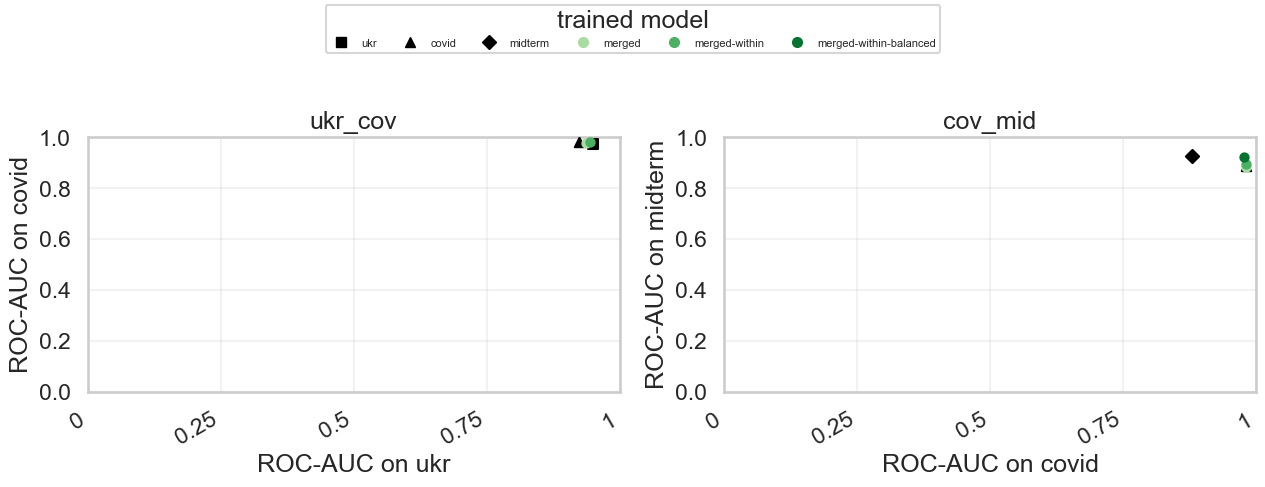

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FuncFormatter

HAS_ADJUST_TEXT = False

experiments = {
    "ukr_cov": ("test_ukr", "test_covid"),
    "cov_mid": ("test_covid", "test_midterm"),
}

plot_df = df[
    df["train"].str.startswith("single_")
    | df["train"].str.endswith("@match")
].copy()

def train_group(train):
    if train.startswith("single_"):
        return "single"

    base = train.removesuffix("@match")

    return {
        "merged_naive": "merged",
        "merged_within": "merged-within",
        "merged_within_balanced": "merged-within-balanced",
    }.get(base, base)

single_trains = list(dict.fromkeys(
    plot_df.loc[plot_df["train"].str.startswith("single_"), "train"]
))

single_marker_cycle = [
    "s",  # square
    "^",  # triangle up
    "D",  # diamond
    "P",  # plus-filled
    "X",  # x-filled
    "v",  # triangle down
    "<",
    ">",
    "p",
    "*",
    "h",
    "8",
]

marker_by_single_train = {
    train: single_marker_cycle[i % len(single_marker_cycle)]
    for i, train in enumerate(single_trains)
}

color_by_group = {
    "single": "black",
    "merged": plt.get_cmap("Greens")(0.35),
    "merged-within": plt.get_cmap("Greens")(0.60),
    "merged-within-balanced": plt.get_cmap("Greens")(0.85),
}

marker_by_group = {
    "merged": "o",
    "merged-within": "o",
    "merged-within-balanced": "o",
}

size_by_group = {
    "single": 45,
    "merged": 35,
    "merged-within": 35,
    "merged-within-balanced": 35,
}

def marker_for_train(train):
    group = train_group(train)
    if group == "single":
        return marker_by_single_train[train]
    return marker_by_group[group]

def color_for_train(train):
    return color_by_group[train_group(train)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

coord_decimals = 3

for ax, (experiment, (x_col, y_col)) in zip(axes, experiments.items()):
    d = plot_df[plot_df["experiment"] == experiment].copy()

    texts = []

    for i, (_, r) in enumerate(d.iterrows()):
        group = train_group(r["train"])
        color = color_for_train(r["train"])
        marker = marker_for_train(r["train"])

        ax.scatter(
            r[x_col],
            r[y_col],
            s=size_by_group[group],
            color=color,
            marker=marker,
            zorder=3,
        )

        label = f"({r[x_col]:.{coord_decimals}f}, {r[y_col]:.{coord_decimals}f})"

        # text = ax.annotate(
        #     label,
        #     xy=(r[x_col], r[y_col]),
        #     xytext=(2 + (i % 3) * 4, 2 + (i % 2) * 5),
        #     textcoords="offset points",
        #     fontsize=9,
        #     rotation=0,
        #     ha="left",
        #     va="bottom",
        #     color=color,
        #     bbox=dict(
        #         boxstyle="round,pad=0.18",
        #         facecolor="white",
        #         edgecolor="none",
        #         alpha=0.75,
        #     ),
        #     zorder=4,
        # )

        # texts.append(text)

    if HAS_ADJUST_TEXT:
        adjust_text(
            texts,
            ax=ax,
            expand_text=(1.15, 1.25),
            expand_points=(1.2, 1.3),
            force_text=(0.4, 0.7),
            force_points=(0.2, 0.4),
            arrowprops=dict(
                arrowstyle="-",
                color="0.55",
                lw=0.5,
                alpha=0.7,
            ),
        )

    ax.set_title(experiment)
    ax.set_xlabel(x_col.replace("test_", "ROC-AUC on "))
    ax.set_ylabel(y_col.replace("test_", "ROC-AUC on "))
    ax.grid(True, alpha=0.25)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"{x:.3f}".rstrip("0").rstrip("."))
    )
    ax.tick_params(axis="x", labelrotation=30)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

    # ax.margins(x=0.08, y=0.12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

single_handles = [
    Line2D(
        [0],
        [0],
        marker=marker_by_single_train[train],
        color="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=7,
        linestyle="None",
        label=train.removeprefix("single_"),
    )
    for train in single_trains
]

merged_legend_order = [
    "merged",
    "merged-within",
    "merged-within-balanced",
]

merged_handles = [
    Line2D(
        [0],
        [0],
        marker=marker_by_group[group],
        color="none",
        markerfacecolor=color_by_group[group],
        markeredgecolor=color_by_group[group],
        markersize=7,
        linestyle="None",
        label=group,
    )
    for group in merged_legend_order
]

fig.legend(
    handles=single_handles + merged_handles,
    title="trained model",
    loc="upper center",
    ncol=min(6, len(single_handles) + len(merged_handles)),
    fontsize=8,
)

plt.tight_layout(rect=[0, 0, 1, 0.84])
plt.show()

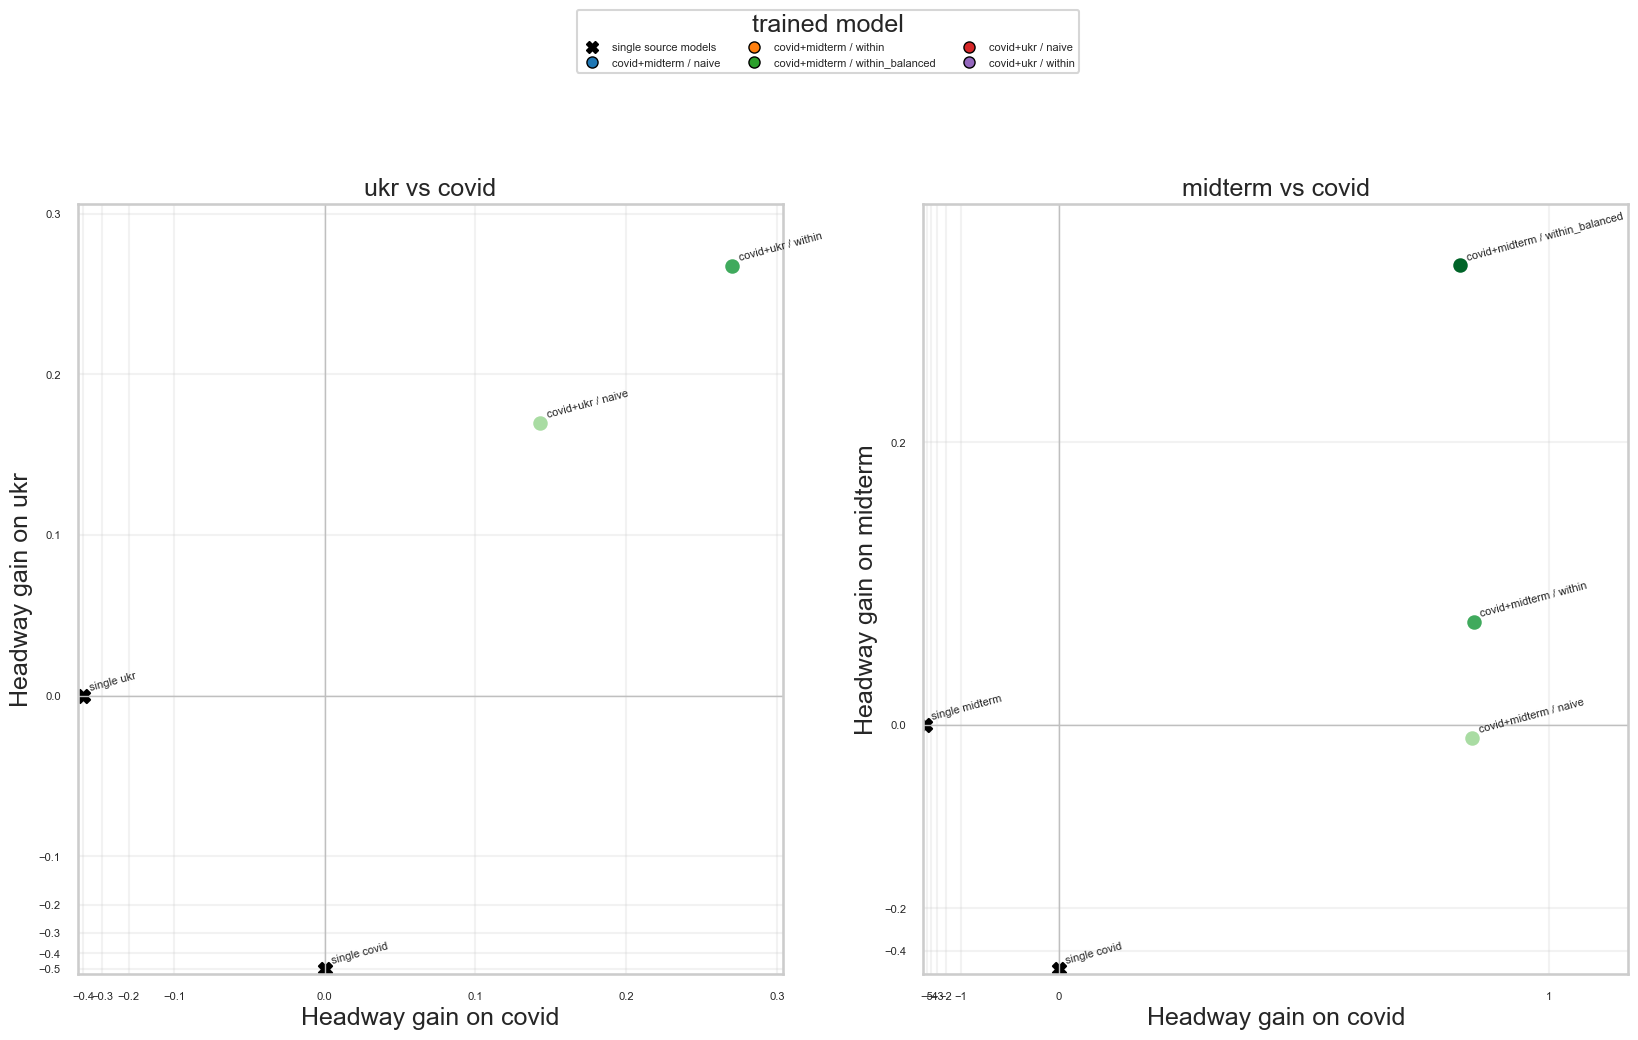

In [201]:
import matplotlib.scale as mscale
import matplotlib.transforms as mtransforms
import matplotlib.ticker as mticker
import numpy as np

class NegLogScale(mscale.ScaleBase):
    name = "neglog"

    def __init__(self, axis, linthresh=0.1, base=10):
        super().__init__(axis)
        self.linthresh = linthresh
        self.base = base

    def get_transform(self):
        return self.NegLogTransform(self.linthresh, self.base)

    def set_default_locators_and_formatters(self, axis):
        axis.set_major_formatter(mticker.ScalarFormatter())

    class NegLogTransform(mtransforms.Transform):
        input_dims = output_dims = 1
        is_separable = True

        def __init__(self, linthresh, base):
            super().__init__()
            self.linthresh = linthresh
            self.base = base

        def transform_non_affine(self, a):
            a = np.asarray(a)
            out = a.copy().astype(float)

            neg = a < -self.linthresh
            out[neg] = -self.linthresh * (
                1 + np.log((-a[neg]) / self.linthresh) / np.log(self.base)
            )

            return out

        def inverted(self):
            return NegLogScale.InvertedNegLogTransform(self.linthresh, self.base)

    class InvertedNegLogTransform(mtransforms.Transform):
        input_dims = output_dims = 1
        is_separable = True

        def __init__(self, linthresh, base):
            super().__init__()
            self.linthresh = linthresh
            self.base = base

        def transform_non_affine(self, a):
            a = np.asarray(a)
            out = a.copy().astype(float)

            neg = a < -self.linthresh
            out[neg] = -self.linthresh * (
                self.base ** ((-a[neg] / self.linthresh) - 1)
            )

            return out

        def inverted(self):
            return NegLogScale.NegLogTransform(self.linthresh, self.base)

mscale.register_scale(NegLogScale)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def headway_gain(auc, control_auc, eps=1e-9):
    return (auc - control_auc) / np.maximum(1 - control_auc, eps)

experiment_graphs = {
    "ukr_cov": ("covid", "ukr"),
    "cov_mid": ("covid", "midterm"),
}

panels = {
    "ukr vs covid": ("covid", "ukr"),
    "midterm vs covid": ("covid", "midterm"),
}

matched = df[df["train"].str.endswith("@match")].copy()
matched["trained_on_graphs"] = matched["experiment"].map(experiment_graphs)
matched["merge_strat"] = (
    matched["train"]
    .str.replace("^merged_", "", regex=True)
    .str.replace("@match$", "", regex=True)
)
matched["model_type"] = "merged_match"
matched["model_label"] = (
    matched["trained_on_graphs"].apply(lambda x: "+".join(x))
    + " / "
    + matched["merge_strat"]
)

rows = []

for panel, (x_graph, y_graph) in panels.items():
    x_col = f"test_{x_graph}"
    y_col = f"test_{y_graph}"

    # Merged models: axis control is the other component of that merged model.
    for _, r in matched.iterrows():
        train_graphs = r["trained_on_graphs"]

        x_controls = [g for g in train_graphs if g != x_graph]
        y_controls = [g for g in train_graphs if g != y_graph]

        if len(x_controls) != 1 or len(y_controls) != 1:
            continue

        x_control_graph = x_controls[0]
        y_control_graph = y_controls[0]

        base = df[df["experiment"] == r["experiment"]]

        x_control_row = base[base["train"] == f"single_{x_control_graph}"]
        y_control_row = base[base["train"] == f"single_{y_control_graph}"]

        if x_control_row.empty or y_control_row.empty:
            continue

        x_control_auc = x_control_row[x_col].iloc[0]
        y_control_auc = y_control_row[y_col].iloc[0]

        rows.append({
            "panel": panel,
            "model_type": "merged_match",
            "trained_on_graphs": train_graphs,
            "train": r["train"],
            "merge_strat": r["merge_strat"],
            "model_label": r["model_label"],
            "x_graph": x_graph,
            "y_graph": y_graph,
            "x_auc": r[x_col],
            "y_auc": r[y_col],
            "x_control_graph": x_control_graph,
            "y_control_graph": y_control_graph,
            "x_control_auc": x_control_auc,
            "y_control_auc": y_control_auc,
            "x_headway_gain": headway_gain(r[x_col], x_control_auc),
            "y_headway_gain": headway_gain(r[y_col], y_control_auc),
        })

        # Single source models for this panel.
    # Own-axis gain is 0; cross-axis compares against the other single source.
    baseline_experiment = next(
        exp for exp, graphs in experiment_graphs.items()
        if set(graphs) == {x_graph, y_graph}
    )
    base = df[df["experiment"] == baseline_experiment]

    x_single = base[base["train"] == f"single_{x_graph}"].iloc[0]
    y_single = base[base["train"] == f"single_{y_graph}"].iloc[0]

    x_own_auc = x_single[x_col]
    y_own_auc = y_single[y_col]

    # single x_graph model: own x axis = 0, transfer to y vs single_y_graph
    rows.append({
        "panel": panel,
        "model_type": "single_source",
        "trained_on_graphs": (x_graph,),
        "train": f"single_{x_graph}",
        "merge_strat": "single",
        "model_label": f"single {x_graph}",
        "x_graph": x_graph,
        "y_graph": y_graph,
        "x_auc": x_single[x_col],
        "y_auc": x_single[y_col],
        "x_control_graph": x_graph,
        "y_control_graph": y_graph,
        "x_control_auc": x_own_auc,
        "y_control_auc": y_own_auc,
        "x_headway_gain": 0.0,
        "y_headway_gain": headway_gain(x_single[y_col], y_own_auc),
    })

    # single y_graph model: transfer to x vs single_x_graph, own y axis = 0
    rows.append({
        "panel": panel,
        "model_type": "single_source",
        "trained_on_graphs": (y_graph,),
        "train": f"single_{y_graph}",
        "merge_strat": "single",
        "model_label": f"single {y_graph}",
        "x_graph": x_graph,
        "y_graph": y_graph,
        "x_auc": y_single[x_col],
        "y_auc": y_single[y_col],
        "x_control_graph": x_graph,
        "y_control_graph": y_graph,
        "x_control_auc": x_own_auc,
        "y_control_auc": y_own_auc,
        "x_headway_gain": headway_gain(y_single[x_col], x_own_auc),
        "y_headway_gain": 0.0,
    })

plot_data = pd.DataFrame(rows)
plot_data

merged_labels = sorted(plot_data.loc[plot_data["model_type"] == "merged_match", "model_label"].unique())
single_labels = sorted(plot_data.loc[plot_data["model_type"] == "single_source", "model_label"].unique())

cmap = plt.get_cmap("tab10")
color_by_label = {label: cmap(i % 10) for i, label in enumerate(merged_labels)}
for label in single_labels:
    color_by_label[label] = "black"
    
merged_trains = sorted(
    t for t in plot_df["train"].unique()
    if not t.startswith("single_")
)

greens = plt.get_cmap("Greens")
green_values = np.linspace(0.35, 0.9, len(merged_trains))

color_by_train = {
    t: greens(v)
    for t, v in zip(merged_trains, green_values)
}

for t in plot_df["train"].unique():
    if t.startswith("single_"):
        color_by_train[t] = "black"

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for ax, (panel, g) in zip(axes, plot_data.groupby("panel", sort=False)):
    for _, r in g.iterrows():
        marker = "X" if r["model_type"] == "single_source" else "o"

        ax.scatter(
            r["x_headway_gain"],
            r["y_headway_gain"],
            s=90 if r["model_type"] == "single_source" else 80,
            color=color_by_train[r["train"]],
            marker=marker,
        )
        ax.annotate(
            r["model_label"],
            (r["x_headway_gain"], r["y_headway_gain"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
            rotation=15,
        )

    x_graph = g["x_graph"].iloc[0]
    y_graph = g["y_graph"].iloc[0]

    ax.axhline(0, color="0.75", lw=1)
    ax.axvline(0, color="0.75", lw=1)
    ax.set_title(panel)
    ax.set_xlabel(f"Headway gain on {x_graph}")
    ax.set_ylabel(f"Headway gain on {y_graph}")
    ax.grid(True, alpha=0.25)
    lin = 0.1
    ax.set_xscale("neglog", linthresh=lin)
    ax.set_yscale("neglog", linthresh=lin)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

handles = [
    Line2D([0], [0], marker="X", color="none", markerfacecolor="black",
           markersize=8, label="single source models")
] + [
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=color_by_label[label], markersize=8, label=label)
    for label in merged_labels
]

fig.legend(
    handles=handles,
    title="trained model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    fontsize=8,
)

# plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.show()

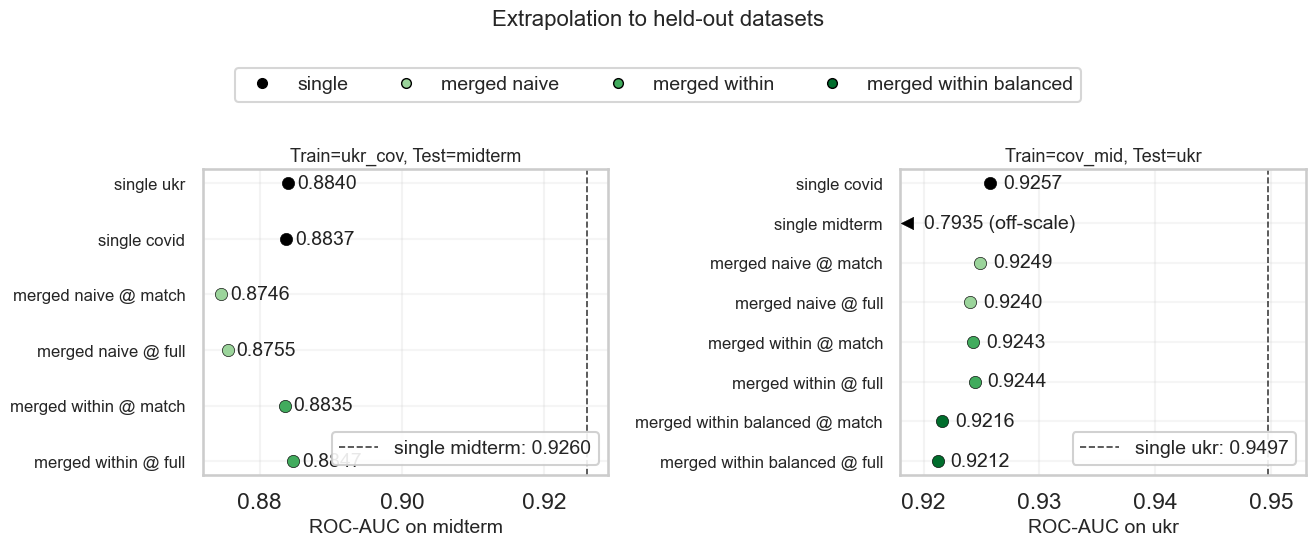

In [217]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DATA = """experiment	train	test_ukr	test_covid	test_midterm	held_out
ukr_cov	single_ukr	0.9497	0.9741	0.884	midterm
ukr_cov	single_covid	0.9245	0.9815	0.8837	midterm
ukr_cov	merged_naive@match	0.9373	0.9778	0.8746	midterm
ukr_cov	merged_naive@full	0.9433	0.9807	0.8755	midterm
ukr_cov	merged_within@match	0.9447	0.9811	0.8835	midterm
ukr_cov	merged_within@full	0.9472	0.9822	0.8847	midterm
cov_mid	single_midterm	0.7935	0.8792	0.926	ukr
cov_mid	single_covid	0.9257	0.9813	0.886	ukr
cov_mid	merged_naive@match	0.9249	0.981	0.8849	ukr
cov_mid	merged_naive@full	0.924	0.9827	0.8899	ukr
cov_mid	merged_within@match	0.9243	0.9814	0.8943	ukr
cov_mid	merged_within@full	0.9244	0.9828	0.8984	ukr
cov_mid	merged_within_balanced@match	0.9216	0.978	0.9231	ukr
cov_mid	merged_within_balanced@full	0.9212	0.9796	0.9291	ukr"""

df = pd.read_csv(io.StringIO(DATA), sep="\t")

score_col = {
    "ukr": "test_ukr",
    "covid": "test_covid",
    "midterm": "test_midterm",
}

recipe_order = [
    "single_ukr",
    "single_covid",
    "single_midterm",
    "merged_naive@match",
    "merged_naive@full",
    "merged_within@match",
    "merged_within@full",
    "merged_within_balanced@match",
    "merged_within_balanced@full",
]

colors = {
    "single": "black",
    "merged_naive": "#9bd49b",
    "merged_within": "#41ab5d",
    "merged_within_balanced": "#006d2c",
}

# Chosen to zoom into the meaningful range while allowing off-scale markers.
panel_xlims = {
    "ukr_cov": (0.872, 0.929),
    "cov_mid": (0.918, 0.953),
}

def family(train):
    if train.startswith("single_"):
        return "single"
    if train.startswith("merged_naive"):
        return "merged_naive"
    if train.startswith("merged_within_balanced"):
        return "merged_within_balanced"
    if train.startswith("merged_within"):
        return "merged_within"
    return "other"

def pretty(train):
    return (
        train.replace("single_", "single ")
             .replace("merged_naive", "merged naive")
             .replace("merged_within_balanced", "merged within balanced")
             .replace("merged_within", "merged within")
             .replace("@", " @ ")
    )

plot_df = df.copy()
plot_df["heldout_auc"] = plot_df.apply(
    lambda r: r[score_col[r["held_out"]]],
    axis=1,
)
plot_df["family"] = plot_df["train"].map(family)
plot_df["label"] = plot_df["train"].map(pretty)
plot_df["order"] = plot_df["train"].map({v: i for i, v in enumerate(recipe_order)})

fig, axes = plt.subplots(
    1,
    plot_df["experiment"].nunique(),
    figsize=(13.5, 4.9),
    sharex=False,
)

if plot_df["experiment"].nunique() == 1:
    axes = [axes]

for ax, (experiment, g) in zip(axes, plot_df.groupby("experiment", sort=False)):
    g = g.sort_values("order", na_position="last").reset_index(drop=True)

    held_out = g["held_out"].iloc[0]
    xcol = score_col[held_out]
    y = np.arange(len(g))

    x_min, x_max = panel_xlims[experiment]
    x_range = x_max - x_min
    offscale_x = x_min + x_range * 0.015

    # Reference line: the single-dataset model trained on the eval dataset.
    ref_train = f"single_{held_out}"
    ref_rows = df[df["train"].eq(ref_train)]
    ref_auc = ref_rows[xcol].max()
    ref_name = pretty(ref_train)

    for yi, row in zip(y, g.itertuples(index=False)):
        actual_x = row.heldout_auc
        is_offscale_left = actual_x < x_min

        plot_x = offscale_x if is_offscale_left else actual_x
        marker = "<" if is_offscale_left else "o"

        ax.scatter(
            plot_x,
            yi,
            s=78,
            marker=marker,
            c=colors[row.family],
            edgecolor="black",
            linewidth=0.45,
            zorder=3,
        )

        if is_offscale_left:
            label = f"{actual_x:.4f} (off-scale)"
            text_x = offscale_x + x_range * 0.018
        else:
            label = f"{actual_x:.4f}"
            text_x = actual_x + x_range * 0.006

        ax.text(
            text_x*1.001,
            yi,
            label,
            va="center",
            ha="left",
            fontsize=14,
            color="#222222",
        )

    ax.axvline(
        ref_auc,
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.75,
        label=f"{ref_name}: {ref_auc:.4f}",
    )

    ax.set_xlim(x_min, x_max)
    ax.set_title(f"Train={experiment}, Test={held_out}", fontsize=13)
    ax.set_yticks(y)
    ax.set_yticklabels(g["label"], fontsize=12)
    ax.invert_yaxis()
    ax.set_xlabel(f"ROC-AUC on {held_out}", fontsize=14)
    ax.grid(axis="x", alpha=0.22)
    ax.grid(axis="y", alpha=0.18)

    ax.legend(
        fontsize=14,
        loc="lower right",
        frameon=True,
        framealpha=0.9,
    )

family_handles = [
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=colors["single"], markeredgecolor="black",
           label="single", markersize=7),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=colors["merged_naive"], markeredgecolor="black",
           label="merged naive", markersize=7),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=colors["merged_within"], markeredgecolor="black",
           label="merged within", markersize=7),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=colors["merged_within_balanced"], markeredgecolor="black",
           label="merged within balanced", markersize=7),
]

fig.legend(
    handles=family_handles,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.03),
    frameon=True,
    fontsize=14,
)

fig.suptitle("Extrapolation to held-out datasets", fontsize=16, y=1.13)
fig.tight_layout()
plt.show()

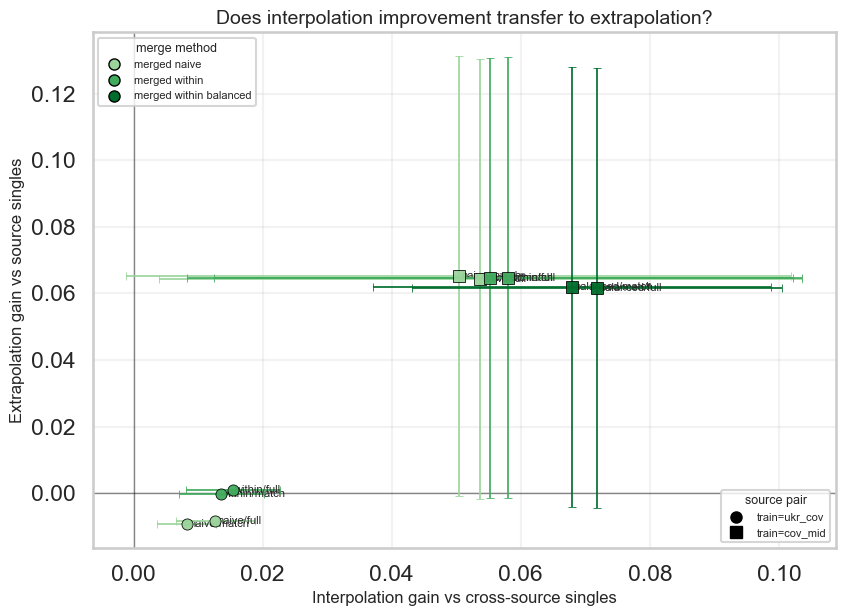

  experiment                         train  interpolation_gain  \
4    cov_mid            merged_naive@match             0.05035   
5    cov_mid             merged_naive@full             0.05370   
6    cov_mid           merged_within@match             0.05525   
7    cov_mid            merged_within@full             0.05800   
8    cov_mid  merged_within_balanced@match             0.06795   
9    cov_mid   merged_within_balanced@full             0.07175   
0    ukr_cov            merged_naive@match             0.00825   
1    ukr_cov             merged_naive@full             0.01270   
2    ukr_cov           merged_within@match             0.01360   
3    ukr_cov            merged_within@full             0.01540   

   interpolation_min  interpolation_max  extrapolation_gain  \
4            -0.0011             0.1018             0.06530   
5             0.0039             0.1035             0.06440   
6             0.0083             0.1022             0.06470   
7             0.0124 

In [214]:
import io
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DATA = """experiment	train	test_ukr	test_covid	test_midterm	held_out
ukr_cov	single_ukr	0.9497	0.9741	0.884	midterm
ukr_cov	single_covid	0.9245	0.9815	0.8837	midterm
ukr_cov	merged_naive@match	0.9373	0.9778	0.8746	midterm
ukr_cov	merged_naive@full	0.9433	0.9807	0.8755	midterm
ukr_cov	merged_within@match	0.9447	0.9811	0.8835	midterm
ukr_cov	merged_within@full	0.9472	0.9822	0.8847	midterm
cov_mid	single_midterm	0.7935	0.8792	0.926	ukr
cov_mid	single_covid	0.9257	0.9813	0.886	ukr
cov_mid	merged_naive@match	0.9249	0.981	0.8849	ukr
cov_mid	merged_naive@full	0.924	0.9827	0.8899	ukr
cov_mid	merged_within@match	0.9243	0.9814	0.8943	ukr
cov_mid	merged_within@full	0.9244	0.9828	0.8984	ukr
cov_mid	merged_within_balanced@match	0.9216	0.978	0.9231	ukr
cov_mid	merged_within_balanced@full	0.9212	0.9796	0.9291	ukr"""

df = pd.read_csv(io.StringIO(DATA), sep="\t")

score_col = {
    "ukr": "test_ukr",
    "covid": "test_covid",
    "midterm": "test_midterm",
}

experiment_sources = {
    "ukr_cov": ("ukr", "covid"),
    "cov_mid": ("covid", "midterm"),
}

colors = {
    "merged naive": "#9bd49b",
    "merged within": "#41ab5d",
    "merged within balanced": "#006d2c",
}

markers = {
    "ukr_cov": "o",
    "cov_mid": "s",
}

def family(train):
    if train.startswith("merged_within_balanced"):
        return "merged within balanced"
    if train.startswith("merged_within"):
        return "merged within"
    if train.startswith("merged_naive"):
        return "merged naive"
    return "other"

def short_label(train):
    return (
        train.replace("merged_naive@", "naive/")
             .replace("merged_within_balanced@", "balanced/")
             .replace("merged_within@", "within/")
    )

rows = []

for experiment, g in df.groupby("experiment", sort=False):
    a, b = experiment_sources[experiment]
    c = g["held_out"].iloc[0]

    single_a = g.loc[g["train"].eq(f"single_{a}")].iloc[0]
    single_b = g.loc[g["train"].eq(f"single_{b}")].iloc[0]

    merged_rows = g[~g["train"].str.startswith("single_")]

    for _, r in merged_rows.iterrows():
        interp_components = [
            r[score_col[b]] - single_a[score_col[b]],  # merged(A,B) vs A on B
            r[score_col[a]] - single_b[score_col[a]],  # merged(A,B) vs B on A
        ]

        extrap_components = [
            r[score_col[c]] - single_a[score_col[c]],  # merged(A,B) vs A on C
            r[score_col[c]] - single_b[score_col[c]],  # merged(A,B) vs B on C
        ]

        rows.append({
            "experiment": experiment,
            "sources": f"{a}+{b}",
            "held_out": c,
            "train": r["train"],
            "label": short_label(r["train"]),
            "family": family(r["train"]),

            "interpolation_gain": sum(interp_components) / len(interp_components),
            "interpolation_min": min(interp_components),
            "interpolation_max": max(interp_components),

            "extrapolation_gain": sum(extrap_components) / len(extrap_components),
            "extrapolation_min": min(extrap_components),
            "extrapolation_max": max(extrap_components),
        })

plot_df = pd.DataFrame(rows)

plot_df["xerr_low"] = plot_df["interpolation_gain"] - plot_df["interpolation_min"]
plot_df["xerr_high"] = plot_df["interpolation_max"] - plot_df["interpolation_gain"]
plot_df["yerr_low"] = plot_df["extrapolation_gain"] - plot_df["extrapolation_min"]
plot_df["yerr_high"] = plot_df["extrapolation_max"] - plot_df["extrapolation_gain"]

fig, ax = plt.subplots(figsize=(8.8, 6.5))

for row in plot_df.itertuples(index=False):
    ax.errorbar(
        row.interpolation_gain,
        row.extrapolation_gain,
        xerr=[[row.xerr_low], [row.xerr_high]],
        yerr=[[row.yerr_low], [row.yerr_high]],
        fmt=markers[row.experiment],
        markersize=8,
        color=colors[row.family],
        markeredgecolor="black",
        markeredgewidth=0.6,
        ecolor=colors[row.family],
        elinewidth=1.3,
        capsize=3,
        alpha=0.95,
        zorder=3,
    )

    ax.text(
        row.interpolation_gain + 0.00035,
        row.extrapolation_gain,
        row.label,
        fontsize=8,
        va="center",
        ha="left",
    )

ax.axhline(0, color="black", linewidth=1, alpha=0.45)
ax.axvline(0, color="black", linewidth=1, alpha=0.45)

ax.set_xlabel("Interpolation gain vs cross-source singles", fontsize=12)
ax.set_ylabel("Extrapolation gain vs source singles", fontsize=12)
ax.set_title("Does interpolation improvement transfer to extrapolation?", fontsize=14)

ax.grid(alpha=0.25)

family_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=color,
        markeredgecolor="black",
        label=name,
        markersize=8,
    )
    for name, color in colors.items()
]

experiment_handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle="none",
        color="black",
        label=f"train={experiment}",
        markersize=8,
    )
    for experiment, marker in markers.items()
]

legend1 = ax.legend(
    handles=family_handles,
    title="merge method",
    loc="upper left",
    frameon=True,
    fontsize=8,
    title_fontsize=9,
)
ax.add_artist(legend1)

ax.legend(
    handles=experiment_handles,
    title="source pair",
    loc="lower right",
    frameon=True,
    fontsize=8,
    title_fontsize=9,
)

fig.tight_layout()
plt.show()

print(
    plot_df[
        [
            "experiment",
            "train",
            "interpolation_gain",
            "interpolation_min",
            "interpolation_max",
            "extrapolation_gain",
            "extrapolation_min",
            "extrapolation_max",
        ]
    ].sort_values(["experiment", "interpolation_gain"])
)

In [213]:
df

,experiment,train,test_ukr,test_covid,test_midterm,held_out
0,ukr_cov,single_ukr,0.9497,0.9741,0.8840,midterm
1,ukr_cov,single_covid,0.9245,0.9815,0.8837,midterm
2,ukr_cov,merged_naive@match,0.9373,0.9778,0.8746,midterm
3,ukr_cov,merged_naive@full,0.9433,0.9807,0.8755,midterm
4,ukr_cov,merged_within@match,0.9447,0.9811,0.8835,midterm
5,ukr_cov,merged_within@full,0.9472,0.9822,0.8847,midterm
6,cov_mid,single_midterm,0.7935,0.8792,0.9260,ukr
7,cov_mid,single_covid,0.9257,0.9813,0.8860,ukr
8,cov_mid,merged_naive@match,0.9249,0.9810,0.8849,ukr
9,cov_mid,merged_naive@full,0.9240,0.9827,0.8899,ukr
